In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score, classification_report, confusion_matrix
from tensorflow.keras import layers, models, metrics
from tensorflow.keras.callbacks import History
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils import class_weight

In [2]:
def load_and_process_session(acc_path, gyr_path, mag_path, labels_path):
    """
    Carica, sincronizza ed etichetta una singola sessione di registrazione.
    """
    acc = pd.read_csv(acc_path, encoding='ISO-8859-1', sep=",")
    gyr = pd.read_csv(gyr_path, encoding='ISO-8859-1', sep=",")
    mag = pd.read_csv(mag_path, encoding='ISO-8859-1', sep=",")
    labels = pd.read_csv(labels_path, encoding='ISO-8859-1', sep=",")

    # Sincronizzazione sui timestamp (Inner Join)
    df = pd.merge(acc, gyr, on='ts', suffixes=('_acc', '_gyr'))
    df = pd.merge(df, mag, on='ts')
    df.rename(columns={'x': 'x_mag', 'y': 'y_mag', 'z': 'z_mag'}, inplace=True)
    df = df.sort_values('ts').reset_index(drop=True)

    # Cast a float32 per risparmiare memoria
    sensor_cols = ['x_acc', 'y_acc', 'z_acc', 'x_gyr', 'y_gyr', 'z_gyr', 'x_mag', 'y_mag', 'z_mag']
    df[sensor_cols] = df[sensor_cols].astype('float32')

    # Labeling
    def get_label(ts):
        match = labels[(labels['ts_start'] <= ts) & (labels['ts_end'] >= ts)]
        if not match.empty:
            return match.iloc[0]['label']
        return None

    df['activity'] = df['ts'].apply(get_label)

    # Mapping e Pulizia
    label_map = {
        'SITTING': 0, 'STANDING': 0, 'LYING': 0,
        'WALKING': 1,
        'CYCLING': 2
    }
    df['target'] = df['activity'].map(label_map)
    df = df.dropna(subset=['target']) # Rimuove dati non etichettati

    print(f"Sessione caricata: {len(df)} campioni validi.")
    return df

In [3]:
def create_windows(df, window_size=256, overlap=128):
    """
    Trasforma il dataset piatto in segmenti temporali (finestre) adatti alla 1D-CNN.

    Parametri:
    - df: DataFrame sincronizzato e filtrato.
    - window_size: Numero di campioni per ogni finestra (256 campioni @200Hz ~= 1.28s).
      Questo intervallo è ideale per catturare almeno un ciclo completo di movimento (una falcata o una pedalata)
    - overlap: Numero di campioni condivisi tra due finestre consecutive (50% di overlap).
      Questo serve a non perdere eventi che potrebbero accadere proprio sul bordo di una finestra
    """

    # Definiamo i 9 canali di input: 3 per l'accelerometro, 3 per il giroscopio, 3 per il magnetometro
    features = ['x_acc', 'y_acc', 'z_acc', 'x_gyr', 'y_gyr', 'z_gyr', 'x_mag', 'y_mag', 'z_mag']
    X, y = [], []

    # Iteriamo attraverso il dataset con un approccio "sliding window"
    for i in range(0, len(df) - window_size, overlap):
        # 1. Estraiamo la finestra di dati inerziali (matrice 256x9)
        window = df[features].iloc[i : i + window_size].values

        # 2. Determiniamo la label della finestra.
        # Poiché una finestra può contenere più attività, assegniamo la label più frequente (la moda).
        label = df['target'].iloc[i : i + window_size].mode()[0]

        # Aggiungiamo i dati e la label alle rispettive liste
        X.append(window)
        y.append(label)

    # Convertiamo le liste in array NumPy per l'addestramento della rete neurale
    # X avrà forma (N_finestre, 256, 9) -> (Batch, TimeSteps, Channels)
    # y avrà forma (N_finestre,)
    return np.array(X), np.array(y)

In [4]:
def plot_feature_distribution(df_feature, feature_name):
    if not isinstance(df_feature, pd.Series):
        df_feature = pd.Series(df_feature)

    counts = df_feature.value_counts().sort_index()
    percentages = df_feature.value_counts(normalize=True).sort_index() * 100

    plt.figure(figsize=(7, 4))
    ax = counts.plot(kind='bar', color='steelblue', edgecolor='black', alpha=0.8)

    labels = [f'{p:.1f}%' for p in percentages]

    ax.bar_label(ax.containers[0], labels=labels, padding=3, fontsize=10, fontweight='bold')

    plt.title(f'Distribuzione della feature: {feature_name}', fontsize=14, fontweight='bold')
    plt.xlabel(feature_name, fontsize=12)
    plt.ylabel('Frequenza', fontsize=12)

    plt.xticks(rotation=45 if len(str(counts.index[0])) > 3 else 0)

    plt.ylim(0, counts.max() * 1.15)

    plt.grid(axis='y', alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()

In [5]:
# CONFIGURAZIONE
seed = 42
features = ['x_acc', 'y_acc', 'z_acc', 'x_gyr', 'y_gyr', 'z_gyr', 'x_mag', 'y_mag', 'z_mag']
WINDOW_SIZE = 256
OVERLAP = 128

In [6]:
#CARICAMENTO DEI 3 DATASET DISTINTI
print("\n Inizio caricamento dataset.")
df_train = load_and_process_session(
    'data/train/smartphone_acc.csv', 'data/train/smartphone_gyr.csv',
    'data/train/smartphone_mag.csv', 'data/train/activity_labels.csv'
)
df_val = load_and_process_session(
    'data/val/smartphone_acc.csv', 'data/val/smartphone_gyr.csv',
    'data/val/smartphone_mag.csv', 'data/val/activity_labels.csv'
)
df_test = load_and_process_session(
    'data/test/smartphone_acc.csv', 'data/test/smartphone_gyr.csv',
    'data/test/smartphone_mag.csv', 'data/test/activity_labels.csv'
)
print("\n Fine caricamento dataset.")


# NORMALIZZAZIONE (FIT SOLO SU TRAIN)
print("\n Inizio Normalizzazione.")
scaler = StandardScaler()
scaler.fit(df_train[features])
df_train[features] = scaler.transform(df_train[features])
df_val[features]   = scaler.transform(df_val[features])
df_test[features]  = scaler.transform(df_test[features])
print("\nNormalizzazione completata.")


# CREAZIONE FINESTRE PER LA 1D CNN
print("Inizio Creazione finestre")
X_train, y_train = create_windows(df_train, WINDOW_SIZE, OVERLAP)
X_val, y_val     = create_windows(df_val, WINDOW_SIZE, OVERLAP)
X_test, y_test   = create_windows(df_test, WINDOW_SIZE, OVERLAP)
print("Fine Creazione finestre")


# DATA SHUFFLE (Solo per il Training)
# È buona norma mescolare le finestre di training in modo che il modello veda batch misti
indices = np.arange(len(X_train))
np.random.shuffle(indices)
X_train = X_train[indices]
y_train = y_train[indices]

print(f"\nDataset Pronti:")
print(f"TRAIN: {X_train.shape} - Classi: {np.unique(y_train, return_counts=True)}")
print(f"VAL:   {X_val.shape}   - Classi: {np.unique(y_val, return_counts=True)}")
print(f"TEST:  {X_test.shape}  - Classi: {np.unique(y_test, return_counts=True)}")


 Inizio caricamento dataset.
Sessione caricata: 154964 campioni validi.
Sessione caricata: 39625 campioni validi.
Sessione caricata: 32689 campioni validi.

 Fine caricamento dataset.

 Inizio Normalizzazione.

Normalizzazione completata.
Inizio Creazione finestre
Fine Creazione finestre

Dataset Pronti:
TRAIN: (1209, 256, 9) - Classi: (array([0., 1., 2.]), array([768, 378,  63]))
VAL:   (308, 256, 9)   - Classi: (array([0., 1., 2.]), array([153,  95,  60]))
TEST:  (254, 256, 9)  - Classi: (array([0., 1., 2.]), array([ 81, 101,  72]))


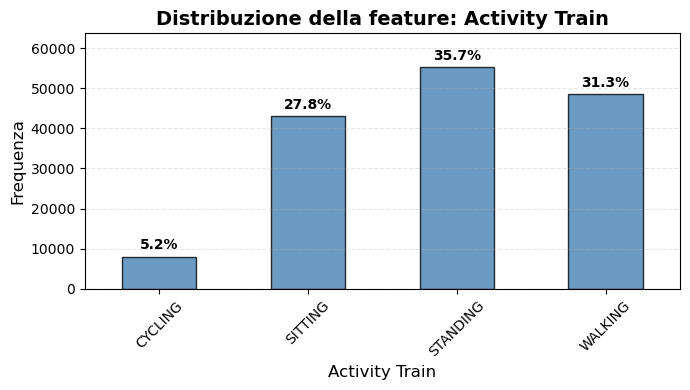

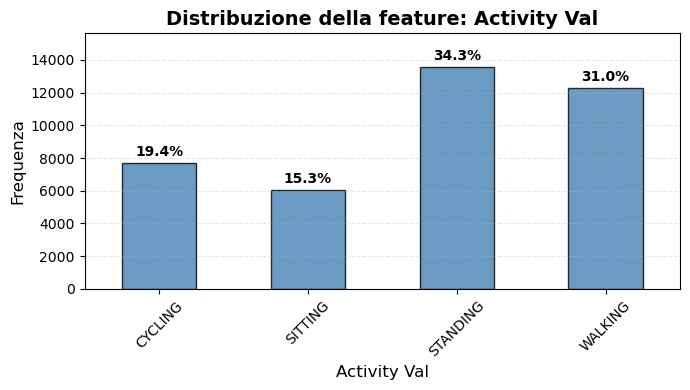

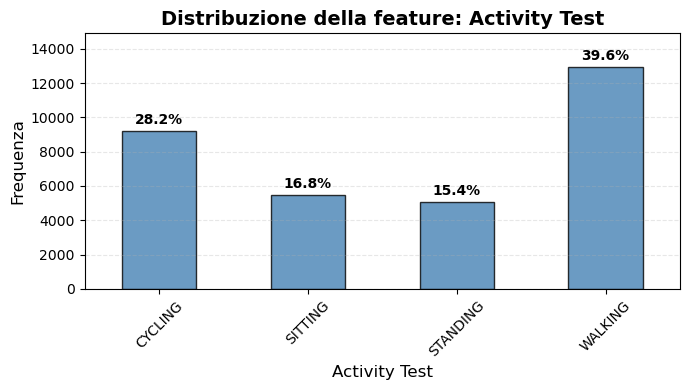

In [7]:
plot_feature_distribution(df_train['activity'], "Activity Train")
plot_feature_distribution(df_val['activity'], "Activity Val")
plot_feature_distribution(df_test['activity'], "Activity Test")

In [11]:
# Calcoliamo i pesi basandoci SOLO su y_train (quello che vede il modello)
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# Convertiamo in dizionario per Keras
class_weight_dict = dict(enumerate(class_weights))

print("Pesi calcolati per bilanciare il training:")
print(f"Classe 0 (Idle):    x{class_weight_dict[0]:.2f}")
print(f"Classe 1 (Walking): x{class_weight_dict[1]:.2f}")
print(f"Classe 2 (Biking):  x{class_weight_dict[2]:.2f}") 

Pesi calcolati per bilanciare il training:
Classe 0 (Idle):    x0.52
Classe 1 (Walking): x1.07
Classe 2 (Biking):  x6.40


In [ ]:
early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True, # Alla fine torna all'epoca migliore
    verbose=1
)

# Riduci il learning rate
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5, 
    patience=3, 
    min_lr=0.00001,
    verbose=1
)

In [ ]:
# VALUTAZIONE SU TEST
print("\n" + "="*60)
print("VALUTAZIONE FINALE SUL TEST SET")
print("="*60)

y_pred = np.argmax(best_model.predict(X_test), axis=1)

print("\nClassification Report:")
class_names = ['Idle (0)', 'Walking (1)', 'Biking (2)']
print(classification_report(y_test, y_pred, target_names=class_names))

print("\nBalanced Accuracy (Test Set):", balanced_accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png')
print("\nConfusion matrix salvata: confusion_matrix.png")
plt.show()